# E-CUP Quality: понятный разбор задачи и данных

Цель notebook — дать практическое понимание соревнования перед генерацией новых гипотез. Здесь мы:

1. разберём, что именно означает целевая метка;
2. посмотрим на баланс категорий и классов;
3. изучим тексты, повторы и противоречивую разметку;
4. разберём три показательных товара с изображениями;
5. поймём, почему наши два лучших решения устроены именно так;
6. сформулируем выводы для следующих экспериментов.

Notebook использует обучающий CSV версии `competition_train_v1`. Изображения нужны только для учебной галереи и не участвуют в расчёте графиков.

## 1. Что означает метка

Категория (`БАД` или `Легковоспламеняющиеся`) уже указана в карточке. Наша задача — проверить, соответствует ли товар этой категории.

| Метка | Смысл | Итоговый вердикт |
|---:|---|---|
| `1` | Категория подтверждается правилами | `не бан` |
| `0` | Категория не подтверждается или действует исключение | `бан` |

Это важное различие. Мы не определяем, опасен ли товар вообще. Например, газовая горелка создаёт огонь, но без газового баллона она по правилам может иметь `label=0`, потому что продаваемый товар не содержит горючего вещества.

In [1]:
from __future__ import annotations

import html
import os
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "assets").exists():
    candidate = Path("notebooks/data_overview_ru")
    if candidate.exists():
        NOTEBOOK_DIR = candidate

default_data = NOTEBOOK_DIR.parents[1] / "research" / "data.csv"
DATA_PATH = Path(os.environ.get("ECUP_DATA_CSV", default_data)).expanduser().resolve()
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден CSV: {DATA_PATH}. Укажите путь в ECUP_DATA_CSV."
    )

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()
df["name"] = df["name"].fillna("").astype(str)
df["description"] = df["description"].fillna("").astype(str)
df["category"] = df["category"].astype(str)
df["label"] = df["label"].astype(int)

print(f"Загружено строк: {len(df):,}".replace(",", " "))
print(f"Файл данных: {DATA_PATH.name} (версия competition_train_v1)")
display(df[["id", "name", "description", "category", "label"]].head(3))

Загружено строк: 12 971
Файл данных: data.csv (версия competition_train_v1)


,id,name,description,category,label
0,0,Now CoQ-10 100 мг 50 капсул улучшает иммунитет,Состав В каждой капсуле биодобавки содержится ...,БАД,1
1,1,"Краски Холи, фестивальные (HOLI) набор 15 шт",Сделайте ваше уникальное мероприятие с набором...,Легковоспламеняющиеся,0
2,2,Мангал складной с шампурами KOLUNDROV Складень...,Мангал складной для шашлыка с 6 шампурами KOLU...,Легковоспламеняющиеся,0


## 2. Размер и целостность таблицы

In [2]:
summary = pd.DataFrame(
    {
        "Показатель": [
            "Строки",
            "Уникальные id",
            "Пропуски в name",
            "Пропуски в description",
            "Полные дубликаты id",
        ],
        "Значение": [
            len(df),
            df["id"].nunique(),
            int(df["name"].str.strip().eq("").sum()),
            int(df["description"].str.strip().eq("").sum()),
            int(df["id"].duplicated().sum()),
        ],
    }
)
display(summary.style.hide(axis="index"))

Показатель,Значение
Строки,12971
Уникальные id,12971
Пропуски в name,0
Пропуски в description,19
Полные дубликаты id,0


## 3. Баланс категорий и меток

Macro F1 одинаково учитывает две категории, хотя положительные примеры распределены очень неравномерно. Особенно важно не потерять 198 положительных примеров категории «Легковоспламеняющиеся»: несколько ошибок заметно меняют итоговый F1.

,category,label,Количество,Смысл
0,БАД,0,1905,бан
1,БАД,1,5564,не бан
2,Легковоспламеняющиеся,0,5304,бан
3,Легковоспламеняющиеся,1,198,не бан


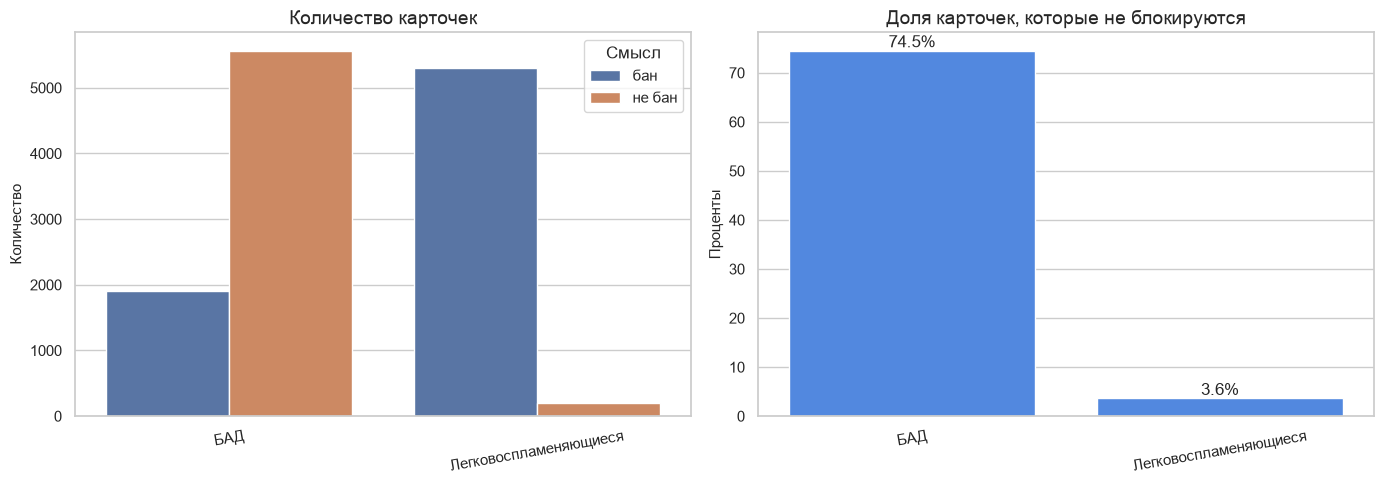

In [3]:
counts = (
    df.groupby(["category", "label"])
      .size()
      .rename("Количество")
      .reset_index()
)
counts["Смысл"] = counts["label"].map({0: "бан", 1: "не бан"})
display(counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=counts, x="category", y="Количество", hue="Смысл", ax=axes[0])
axes[0].set_title("Количество карточек")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=10)

rates = df.groupby("category")["label"].agg(["sum", "count"])
rates["Доля label=1, %"] = 100 * rates["sum"] / rates["count"]
sns.barplot(x=rates.index, y=rates["Доля label=1, %"], color="#3b82f6", ax=axes[1])
axes[1].set_title("Доля карточек, которые не блокируются")
axes[1].set_xlabel("")
axes[1].set_ylabel("Проценты")
axes[1].tick_params(axis="x", rotation=10)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

**Как это читать.** Для БАД большинство карточек подтверждают категорию. Для легковоспламеняющихся почти все карточки получают `бан`: продавцы часто указывают категорию слишком широко, хотя топливо отсутствует, источник встроен или опасный предмет не входит в комплект. Одна общая граница решения для обеих категорий поэтому была бы ошибкой.

## 4. Сколько информации находится в тексте

In [4]:
TAG_RE = re.compile(r"<[^>]+>")

def clean_text(value: str) -> str:
    value = html.unescape(str(value or ""))
    value = TAG_RE.sub(" ", value)
    return re.sub(r"\s+", " ", value).strip()

df["name_clean"] = df["name"].map(clean_text)
df["description_clean"] = df["description"].map(clean_text)
df["name_chars"] = df["name_clean"].str.len()
df["description_chars"] = df["description_clean"].str.len()
df["description_words"] = df["description_clean"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=df,
    x="category",
    y="description_words",
    hue="label",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("Длина описания без крайних выбросов")
axes[0].set_xlabel("")
axes[0].set_ylabel("Количество слов")
axes[0].tick_params(axis="x", rotation=10)

for category, part in df.groupby("category"):
    sns.ecdfplot(data=part, x="description_words", label=category, ax=axes[1])
axes[1].set_xlim(0, df["description_words"].quantile(0.98))
axes[1].set_title("Накопленное распределение длины")
axes[1].set_xlabel("Количество слов")
axes[1].legend()
plt.tight_layout()
plt.show()

display(
    df.groupby(["category", "label"])[["name_chars", "description_words"]]
      .median()
      .round(1)
      .rename(columns={"name_chars": "Медиана символов в названии", "description_words": "Медиана слов в описании"})
)

Медиана символов в названии  \
category              label                                
БАД                   0                             71.0   
                      1                             57.0   
Легковоспламеняющиеся 0                             55.0   
                      1                             58.0   

                             Медиана слов в описании  
category              label                           
БАД                   0                        208.0  
                      1                        189.0  
Легковоспламеняющиеся 0                        127.0  
                      1                         91.0

Большой объём текста не гарантирует полезности. Описания содержат рекламу, повторения и HTML, а решающая фраза может состоять из двух слов. Поэтому первая сильная модель сочетает слова и части слов, а Qwen получает правила категории прямо во входных данных.

## 5. Простые маркеры и почему одних правил недостаточно

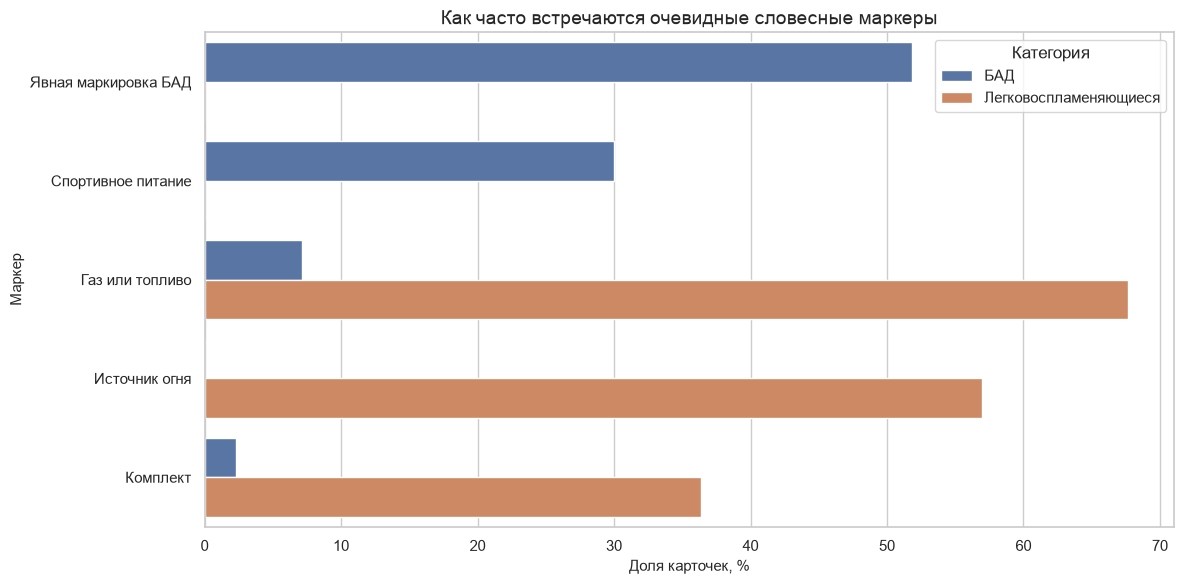

,Доля label=0,Доля label=1
Маркер отсутствует,25.9%,74.1%
Маркер присутствует,25.1%,74.9%


In [5]:
full_text = (df["name_clean"] + " " + df["description_clean"]).str.lower().str.replace("ё", "е")
patterns = {
    "Явная маркировка БАД": r"(?<![а-яa-z])бад(?![а-яa-z])|dietary\s+supplement",
    "Спортивное питание": r"bcaa|бцаа|l[- ]?карнит|протеин|аминокислот|спортивн(?:ое|ого) питан",
    "Газ или топливо": r"газ|бутан|пропан|бензин|топлив",
    "Источник огня": r"зажигал|спичк|горелк|поджиг",
    "Комплект": r"комплект|в комплекте|поставк",
}

marker_rows = []
for title, pattern in patterns.items():
    mask = full_text.str.contains(pattern, regex=True, na=False)
    for category in df["category"].unique():
        part = mask[df["category"].eq(category)]
        marker_rows.append(
            {"Маркер": title, "Категория": category, "Доля карточек, %": 100 * part.mean()}
        )
marker_df = pd.DataFrame(marker_rows)

plt.figure(figsize=(12, 6))
sns.barplot(data=marker_df, y="Маркер", x="Доля карточек, %", hue="Категория")
plt.title("Как часто встречаются очевидные словесные маркеры")
plt.tight_layout()
plt.show()

bad = df["category"].eq("БАД")
explicit_bad = full_text.str.contains(patterns["Явная маркировка БАД"], regex=True, na=False)
rule_table = pd.crosstab(explicit_bad[bad], df.loc[bad, "label"], normalize="index")
rule_table.index = ["Маркер отсутствует", "Маркер присутствует"]
rule_table.columns = ["Доля label=0", "Доля label=1"]
display(rule_table.style.format("{:.1%}"))

Даже сильный маркер не даёт идеального правила: встречаются отрицания, реклама, упоминание чужого товара и ошибки разметки. Именно поэтому наши жёсткие правила ухудшали F1, а словесные признаки полезнее передавать обучаемой модели.

## 6. Повторяющиеся товарные семейства

,Повторяющиеся группы,Строки в повторяющихся группах,Группы с разными метками
Одинаковое название,1868,5994,66
Одинаковые название и описание,1802,5401,55


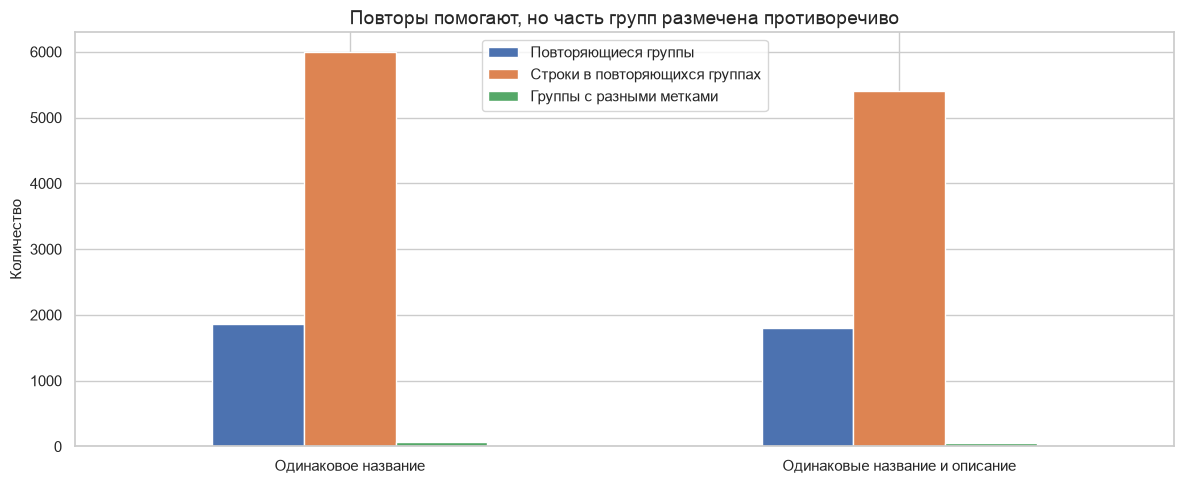

In [6]:
def normalize_family(value: str) -> str:
    value = clean_text(value)
    value = unicodedata.normalize("NFKC", value).lower().replace("ё", "е")
    value = re.sub(r"[^0-9a-zа-я]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()

df["name_family"] = df["name"].map(normalize_family)
df["full_text_family"] = (
    df["name"].map(normalize_family) + " " + df["description"].map(normalize_family)
).str.strip()

def family_stats(column: str) -> dict[str, int]:
    grouped = df.groupby(["category", column], dropna=False)
    sizes = grouped.size()
    conflicts = grouped["label"].nunique()
    repeated = sizes[sizes > 1]
    return {
        "Повторяющиеся группы": int(len(repeated)),
        "Строки в повторяющихся группах": int(repeated.sum()),
        "Группы с разными метками": int((conflicts > 1).sum()),
    }

family_summary = pd.DataFrame(
    {
        "Одинаковое название": family_stats("name_family"),
        "Одинаковые название и описание": family_stats("full_text_family"),
    }
).T
display(family_summary)

family_summary.plot(kind="bar", figsize=(12, 5))
plt.title("Повторы помогают, но часть групп размечена противоречиво")
plt.xlabel("")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Это один из главных фактов задачи. Тысячи строк относятся к повторяющимся товарам, поэтому память о товарном семействе может быть очень сильной. Но десятки семейств содержат разные метки. Следовательно, нельзя безусловно копировать ответ ближайшего соседа: нужна оценка согласованности и уверенности.

При проверке качества все карточки одного семейства должны находиться в одной части. Иначе модель фактически увидит тот же товар и получит завышенную оценку.

## 7. Три карточки, которые объясняют смысл задачи

In [7]:
example_ids = [4424, 5192, 4040]
examples = df[df["id"].isin(example_ids)][
    ["id", "category", "label", "name_clean", "description_clean"]
].copy()
examples["Вердикт"] = examples["label"].map({1: "не бан", 0: "бан"})
examples["description_clean"] = examples["description_clean"].str.slice(0, 420) + "…"
display(examples.rename(columns={"name_clean": "Название", "description_clean": "Начало описания"}))

,id,category,label,Название,Начало описания,Вердикт
2854,4040,Легковоспламеняющиеся,0,Газовая горелка с пъезоподжигом на баллончик A...,Газовая горелка с пьезоподжигом на баллон - эт...,бан
3119,4424,БАД,1,Расторопша БАД для печени очищение и восстанов...,"Описание:Расторопша-это экстракт расторопши, к...",не бан
3669,5192,БАД,0,IMBIAN PHARM Премиальный Морской коллаген для ...,"Морской коллаген для красоты, Премиум 8000 мг ...",бан


### Товар 4424: подтверждённый БАД (`label=1`, `не бан`)

<div style="display:flex; gap:12px; align-items:flex-start">
  <img src="assets/images/4424/0.jpg" width="260" alt="Расторопша, первое изображение">
  <img src="assets/images/4424/1.jpg" width="260" alt="Расторопша, второе изображение">
</div>

Название прямо содержит «БАД», а упаковка подтверждает формат добавки. Здесь текст и изображение согласованы.

### Товар 5192: похож на добавку, но получает бан (`label=0`)

<div style="display:flex; gap:8px; flex-wrap:wrap; align-items:flex-start">
  <img src="assets/images/5192/0.jpg" width="190" alt="Коллаген, изображение 1">
  <img src="assets/images/5192/1.jpg" width="190" alt="Коллаген, изображение 2">
  <img src="assets/images/5192/2.jpg" width="190" alt="Коллаген, изображение 3">
</div>

Коллаген выглядит как полезная пищевая добавка, но похожести недостаточно: требуется явная маркировка БАД или `dietary supplement`. Это пример, где модель должна следовать правилам, а не бытовой интуиции.

### Товар 4040: горелка без топлива (`label=0`, `бан`)

<div style="display:flex; gap:8px; flex-wrap:wrap; align-items:flex-start">
  <img src="assets/images/4040/0.jpg" width="190" alt="Газовая горелка, изображение 1">
  <img src="assets/images/4040/1.jpg" width="190" alt="Газовая горелка, изображение 2">
  <img src="assets/images/4040/2.jpg" width="190" alt="Газовая горелка, изображение 3">
</div>

Горелка создаёт пламя, но продаётся без баллона. По условиям пустое оборудование и встроенный поджиг не подтверждают категорию. Для решения важны состав комплекта и продаваемое содержимое, а не только слово «газовая».

## 8. Сколько изображений у товара

Полный проверенный архив содержит 49 456 изображений. Распределение количества изображений на товар было посчитано при полном аудите S3-архива. Здесь оно приведено как зафиксированный результат; если задан `ECUP_IMAGES_DIR`, следующая ячейка может пересчитать его локально.

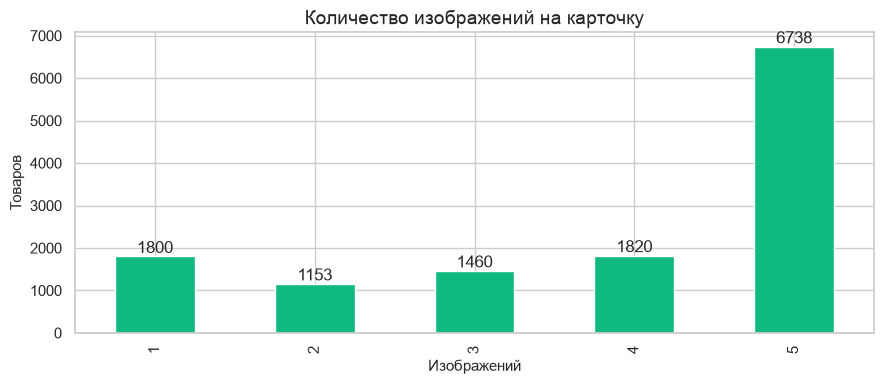

Зафиксированный полный аудит архива


In [8]:
known_image_distribution = pd.Series(
    {1: 1800, 2: 1153, 3: 1460, 4: 1820, 5: 6738},
    name="Количество товаров",
)
known_image_distribution.index.name = "Изображений у товара"

images_root_env = os.environ.get("ECUP_IMAGES_DIR")
if images_root_env:
    images_root = Path(images_root_env).expanduser().resolve()
    actual = {}
    for product_dir in images_root.iterdir():
        if product_dir.is_dir():
            count = sum(
                p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
                for p in product_dir.iterdir() if p.is_file()
            )
            if count:
                actual[count] = actual.get(count, 0) + 1
    image_distribution = pd.Series(actual, name="Количество товаров").sort_index()
    source_note = f"Пересчитано по {images_root}"
else:
    image_distribution = known_image_distribution
    source_note = "Зафиксированный полный аудит архива"

ax = image_distribution.plot(kind="bar", color="#10b981", figsize=(9, 4))
ax.set_title("Количество изображений на карточку")
ax.set_xlabel("Изображений")
ax.set_ylabel("Товаров")
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()
print(source_note)

У большинства товаров пять изображений, но проверенный опыт показал, что передача всех снимков в дообученную Qwen ухудшает качество. Дополнительные рекламные кадры размывают решающий сигнал. Поэтому сильное решение использует первое изображение для LoRA-моделей, а полный набор — только в отдельной модели представлений.

## 9. Два лучших решения

### Первое: текст + зрительно-текстовое представление — Public 0.806579

1. Отдельная линейная модель анализирует слова и части слов в названии и описании.
2. `Qwen3-VL-Embedding-2B` превращает текст и изображения в числовое представление; вторая линейная модель работает с ним.
3. Оценки объединяются отдельно для каждой категории. Для БАД важнее текст, для легковоспламеняющихся выше вес изображения.
4. Согласованные точные повторы получают известную метку семейства.

Сила решения — в независимости двух источников. Слабость — ограниченное понимание сложных исключений.

### Второе: базовое решение + две дообученные Qwen + товарные семейства — Public 0.891924

1. Сохраняется устойчивое первое решение.
2. `Qwen3-VL-2B-Instruct` и `Qwen3.5-4B` отдельно дообучаются небольшими LoRA-адаптерами на правилах задачи и первом изображении.
3. Для БАД три мнения получают веса 50/25/25. Для легковоспламеняющихся Qwen3.5 получает 75% веса, потому что лучше понимает комплект и исключения.
4. После моделей проверяются точное совпадение, одинаковое название, числовой вариант товара и редкие общие фразы. Последний способ применяется только для БАД.

Сила решения — сочетание текста, изображения, понимания правил и повторяемости товаров. Риск — противоречивые метки внутри похожих семейств.

## 10. Практические выводы для новых гипотез

1. **Категории требуют разных моделей и границ решения.** Дисбаланс и характер правил слишком различаются.
2. **Явное доказательство важнее внешнего вида.** Для БАД нужно найти маркировку; для горючих товаров — подтвердить содержимое или комплект.
3. **Повторы — сильнейший дополнительный источник, но не абсолютная истина.** Нужна вероятность метки семейства и оценка согласованности.
4. **Разметка содержит неоднозначность.** Следует уменьшать влияние систематически спорных примеров, а не просто удалять их.
5. **Первое изображение обычно полезнее всей галереи.** Следующий зрительный опыт должен искать конкретное доказательство, например участок с маркировкой.
6. **Редкая категория требует отдельного разбора свойств.** Полезно предсказывать наличие топлива, самостоятельный источник огня, встроенный поджиг и состав комплекта.
7. **Нельзя доверять случайному разбиению.** Товарные семейства должны целиком находиться в одной части проверки.

Следующий разумный шаг после знакомства с данными — вручную просмотреть по 30–50 ошибок каждого типа и превратить повторяющиеся причины в проверяемые гипотезы.